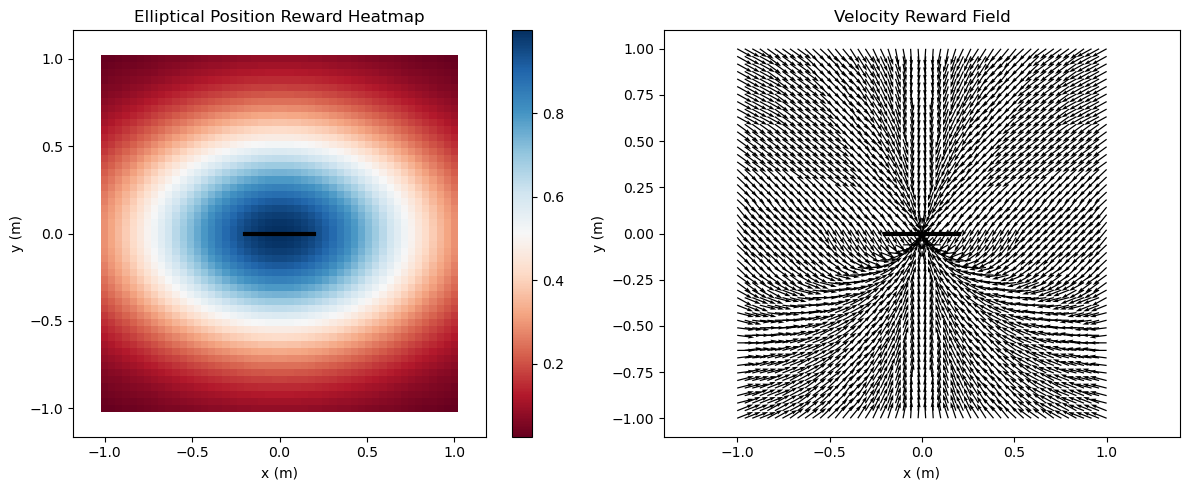

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# ------------------------
# 参数设定
# ------------------------
gate_pos = np.array([0.0, 0.0])      # 门在原点
gate_width = 0.4                     # 门宽度 (m)
gate_normal = np.array([0.0, 1.0])   # 门法向量 (y 方向)
gate_tangent = np.array([1.0, 0.0])  # 横向方向 (x 方向)

# ------------------------
# 椭圆位置奖励函数
# ------------------------
def compute_position_reward(x, y, a_scale=0.4, b_scale=0.9):
    pos = np.stack([x, y], axis=-1)        
    rel_gate = gate_pos - pos              # (H, W, 2)

    # 投影到横向/纵向
    u = -rel_gate @ gate_tangent
    v = -rel_gate @ gate_normal

    # 椭圆奖励函数
    r_pos = np.exp(- (u**2 / a_scale**2 + v**2 / b_scale**2))
    return r_pos, rel_gate

# ------------------------
# 速度奖励函数
# ------------------------
def compute_velocity_field(x, y, rel_gate, k_gates=1.0, k_center_d=0.8, k_prog=2.0, n_dirs=50):
    H, W = x.shape
    U = np.zeros_like(x)
    V = np.zeros_like(y)

    # 候选速度方向
    angles = np.linspace(0, 2*np.pi, n_dirs, endpoint=False)
    dirs = np.stack([np.cos(angles), np.sin(angles)], axis=-1)  # (n_dirs, 2)

    for i in range(H):
        for j in range(W):
            rg = rel_gate[i, j]
            if np.linalg.norm(rg) < 1e-6:
                continue

            rg_hat = rg / np.linalg.norm(rg)

            # (1) 朝向门的速度奖励
            r_gate_vel = k_gates * (dirs @ rg_hat)

            # (2) 中心线速度奖励 (vec_center 分量)
            dot_rg = rg @ gate_normal
            vc = rg - gate_normal * dot_rg
            r_center_d = k_center_d * (dirs @ vc)

            # (3) 绕开门框奖励
            dot_n = rg @ gate_normal
            ratio = (dot_n**2) / (np.linalg.norm(rg)**2 + 1e-6)
            exp_factor = np.exp(-5 * ratio)
            r_prog = k_prog * (-(dirs @ gate_normal)) * exp_factor

            # 合成总奖励
            rewards = r_gate_vel + r_center_d + r_prog
            best_idx = np.argmax(rewards)
            U[i, j], V[i, j] = dirs[best_idx]

    return U, V

# ------------------------
# 可视化函数
# ------------------------
def plot_rewards(a_scale=0.4, b_scale=0.9, k_gates=1.0, k_center_d=0.8, k_prog=2.0):
    xs = np.linspace(-1.0, 1.0, 50)
    ys = np.linspace(-1.0, 1.0, 50)
    X, Y = np.meshgrid(xs, ys)

    # 计算奖励
    r_pos, rel_gate = compute_position_reward(X, Y, a_scale, b_scale)

    plt.figure(figsize=(12, 5))

    # --- 位置奖励热力图 ---
    plt.subplot(1, 2, 1)
    plt.title("Elliptical Position Reward Heatmap")
    im = plt.pcolormesh(X, Y, r_pos, cmap='RdBu')
    plt.colorbar(im)
    # 画门线段
    plt.plot([-gate_width/2, gate_width/2], [0, 0], 'k-', linewidth=3)
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.axis("equal")

    # --- 速度奖励势场图 ---
    plt.subplot(1, 2, 2)
    plt.title("Velocity Reward Field")
    U, V = compute_velocity_field(X, Y, rel_gate, k_gates, k_center_d, k_prog)
    plt.quiver(X, Y, U, V, scale=30)
    # 画门线段
    plt.plot([-gate_width/2, gate_width/2], [0, 0], 'k-', linewidth=3)
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.axis("equal")

    plt.tight_layout()
    plt.show()

plot_rewards()